Menampilkan Raw Data

In [11]:
import pandas as pd

# Simulasi Raw Data hasil scraping
raw_data = pd.DataFrame({
    'Review_ID': [1, 2, 3, 4, 5],
    'User_Name': ['Andi', 'Budi', 'Cici', 'Dedi', 'Eti'],
    'Review_Text': [
        'Aplikasi ini bagus banget!! Sangat membantu sehari-hari',
        'Kecewa, aplikasinya sering lag dan keluar sendiri',
        'Biasa aja sih, fitur layanannya perlu ditingkatkan lagi',
        'Sangat puas dengan responn cs yang cepat dan ramah.',
        pd.NA # Ada data kosong
    ]
})

print("--- RAW DATA (HASIL SCRAPING) ---")
print(raw_data)

--- RAW DATA (HASIL SCRAPING) ---
   Review_ID User_Name                                        Review_Text
0          1      Andi  Aplikasi ini bagus banget!! Sangat membantu se...
1          2      Budi  Kecewa, aplikasinya sering lag dan keluar sendiri
2          3      Cici  Biasa aja sih, fitur layanannya perlu ditingka...
3          4      Dedi  Sangat puas dengan responn cs yang cepat dan r...
4          5       Eti                                               <NA>


Proses Cleaning & Slicing Data Mentah

In [12]:
import pandas as pd

# 1. Cleaning & Slicing: Menghapus baris kosong dan mengambil kolom teks saja
cleaned_data = raw_data.dropna(subset=['Review_Text']).copy()
cleaned_data = cleaned_data[['Review_Text']]

# 2. Simulasi Analisis Sentimen (Pelabelan otomatis/manual)
cleaned_data['Sentiment'] = ['Positif', 'Negatif', 'Netral', 'Positif']

# 3. Ekstrasi Fitur Teks ke Angka (Simulasi TF-IDF Matrix dengan banyak kolom)
# Misal dihasilkan 199 fitur kata, lalu kita 'slice' dimensinya menggunakan PCA
from sklearn.decomposition import PCA
import numpy as np

# Simulasi 199 fitur teks dari TF-IDF
np.random.seed(42)
tfidf_features = np.random.rand(len(cleaned_data), 199) # Simulate 199 features for each review

# Inisialisasi objek PCA dan lakukan transformasi
pca = PCA(n_components=2)
pca_features = pca.fit_transform(tfidf_features)

print("--- DATA SETELAH PREPROCESSING & PCA (2 KOMPONEN UTAMA) ---")
print(pca_features)

--- DATA SETELAH PREPROCESSING & PCA (2 KOMPONEN UTAMA) ---
[[-2.59054925  0.31427126]
 [ 2.22092101  2.95472403]
 [ 2.15716807 -2.93850218]
 [-1.78753982 -0.33049311]]


Output Grafik (Multi-Model)

Model 1: Unsupervised Learning (Elbow Method & PCA Clustering)

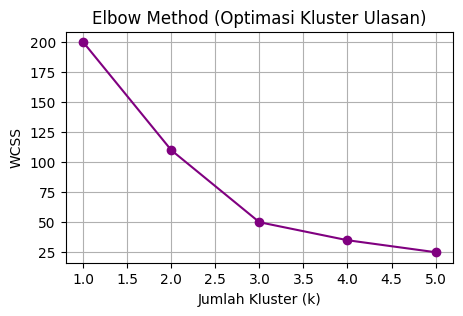

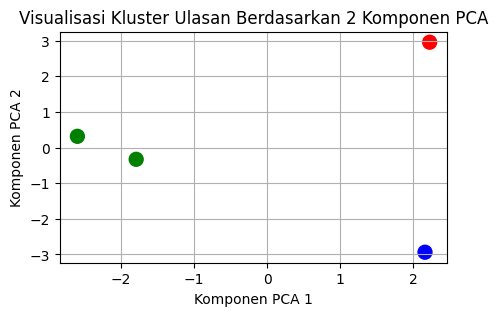

In [13]:
import matplotlib.pyplot as plt

# Grafik A: Elbow Method untuk menentukan jumlah Kluster terbaik
wcss = [200, 110, 50, 35, 25] # Contoh simulasi WCSS
plt.figure(figsize=(5, 3))
plt.plot(range(1, 6), wcss, marker='o', color='purple')
plt.title('Elbow Method (Optimasi Kluster Ulasan)')
plt.xlabel('Jumlah Kluster (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# Grafik B: Visualisasi Hasil Clustering pada Fitur PCA
plt.figure(figsize=(5, 3))
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=['green', 'red', 'blue', 'green'], s=100)
plt.title('Visualisasi Kluster Ulasan Berdasarkan 2 Komponen PCA')
plt.xlabel('Komponen PCA 1')
plt.ylabel('Komponen PCA 2')
plt.grid(True)
plt.show()

Model 2: Supervised Learning (Perbandingan Model Klasifikasi Sentimen)

/tmp/ipykernel_9535/711825559.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=akurasi_skor, palette='Set2')


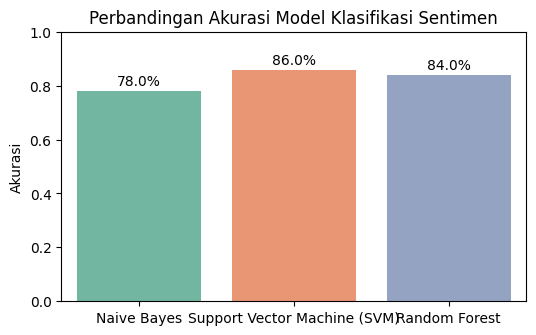

In [14]:
import seaborn as sns

# Komparasi performa semua model klasifikasi terpisah
model_names= ['Naive Bayes', 'Support Vector Machine (SVM)', 'Random Forest']
akurasi_skor = [0.78, 0.86, 0.84]

plt.figure(figsize=(6, 3.5))
sns.barplot(x=model_names, y=akurasi_skor, palette='Set2')
plt.title('Perbandingan Akurasi Model Klasifikasi Sentimen')
plt.ylabel('Akurasi')
plt.ylim(0, 1)
for i, v in enumerate(akurasi_skor):
    plt.text(i, v + 0.02, f"{v*100}%", ha='center')
plt.show()